# Notebook 07 — Thompson sampling cadence

This notebook varies one Bayesian-internal hyperparameter — the *cadence*
at which Thompson sampling redraws from the posterior during a rollout —
and characterises how much it matters on this dataset.

It is **not** a Bayesian-vs-classical comparison: the headline regime
elsewhere in the project is per-episode posterior sampling (Osband-style
PSRL, `resample_every=None`), and nb 09 already settled the calibration
question. Here we hold the Gaussian SPY posterior fixed and sweep the
cadence over three values:

- **per-episode** (`resample_every=None`): one posterior draw is held
  fixed across the whole test window. Textbook PSRL — "I commit to one
  belief about the world for one trading episode and act consistently
  under it."
- **monthly** (`resample_every=20`, ~one trading month): redraw every
  20 valid steps. Intermediate stress-test of the cadence axis.
- **per-step** (`resample_every=1`): redraw every valid step. Textbook
  bandit Thompson — "each timestep is a fresh draw from the posterior."

The two extremes correspond to different epistemic claims; the middle
value is included to see whether the metric surface is monotone or
non-monotone in the cadence parameter.

The headline measurements are:

1. The per-timestep **cross-path action diversity** — Shannon entropy of
   the action distribution across the 500 posterior rollouts at each
   test-window day, normalised by `log 3` (Pielou evenness, on the unit
   interval). This is a marginal-posterior diagnostic at each state.
2. **Turnover** — the within-path mean `|a_t - a_{t-1}|`, the standard
   handle on how much the policy churns its position. Cadence affects
   this directly: under per-step Thompson, every step is a fresh
   posterior draw and consecutive actions decorrelate.
3. The headline scalar metrics — Sharpe, max drawdown — and whether
   their 95% credible intervals overlap across the three cadences.

A subtle point on (1): the cross-path entropy at a fixed timestep is a
function of the posterior over the argmax-action at the state observed
that day. It does *not* directly depend on cadence — both per-episode
and per-step paths generate (effectively) iid posterior draws at each
state, just differently correlated across time. The cadence-sensitive
half of "action diversity" lives in (2), not (1).

**Inputs**

- Cached SPY data + features (no fresh downloads).
- `data/processed/traces/gaussian_*.pkl` — produced by nb 03.
- `data/processed/paths/paths_gaussian_*.pkl` — the per-episode rollout
  cache from nb 04 is reused.

**Outputs**

- Two new path caches under `data/processed/paths/` for the
  monthly and per-step cadences.

**Runtime**: cold ~60 s (two new 500-path rollouts at ~30 s each).
Warm: <30 s (every cache hits).


In [1]:
import sys
from pathlib import Path

NB_ROOT = Path.cwd().resolve()
SRC = NB_ROOT.parent / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import hashlib
import pickle
import time

import numpy as np
import pandas as pd
from IPython.display import display

from project import data, features, plots, rollout, thompson
from project import eval as ev
from project.utils import set_seed, ensure_dirs

ensure_dirs()
rng = set_seed()
SEED = 12345
N_PATHS = 500

TRACE_DIR = Path("../data/processed/traces")
PATHS_DIR = Path("../data/processed/paths")
PATHS_DIR.mkdir(parents=True, exist_ok=True)

spy = data.load_spy()
splits = data.split_windows(spy)
prices_test = splits["test"]
feat = features.build_features(spy)
feat_test = feat.reindex(prices_test.index)

print(f"prices_test:    {prices_test.index[0].date()}  to  {prices_test.index[-1].date()}")
print(f"prices_test:    {len(prices_test)} rows")
print(f"feat_test cols: {list(feat_test.columns)}")


prices_test:    2020-01-02  to  2026-04-29
prices_test:    1589 rows
feat_test cols: ['x1_mom', 'x2_logvol', 'x3_p_vs_ma', 'x4_intercept']


## The cadence design choice

`simulate_path` exposes the cadence via `resample_every`:

- `None` is per-episode PSRL — one `idx ~ Uniform(0, n_draws_total)` is
  drawn at rollout start and held for every step.
- `1` is per-step Thompson — a fresh `idx` is drawn before every action.
- `k > 1` is the intermediate regime — `idx` is redrawn every `k` valid
  steps.

The two extremes have textbook standing in different literatures
(Osband, Russo, Van Roy 2013 for PSRL; Russo et al. 2018 for
bandit-style Thompson). Within an episode they make different epistemic
commitments. The monthly cadence is included as a stress-test of the
single design knob; nothing in the project's other claims depends on
which cadence we end up preferring here.


In [2]:
def _trace_hash_from_filename(path: Path) -> str:
    return path.stem.rsplit("_", 1)[-1]


def _load_trace(sampler_name: str) -> tuple[dict, str, Path]:
    matches = sorted(TRACE_DIR.glob(f"{sampler_name}_*.pkl"))
    if not matches:
        raise FileNotFoundError(
            f"No cached {sampler_name} trace under {TRACE_DIR}/. "
            "Run nb 03 first to populate it."
        )
    p = matches[0]
    with open(p, "rb") as f:
        return pickle.load(f), _trace_hash_from_filename(p), p


trace_g, hash_g, path_g = _load_trace("gaussian")
policy_g = thompson.policy_from_trace(trace_g)
print(f"Loaded Gaussian trace: {path_g.name}")
print(f"  beta shape          = {trace_g['beta'].shape}  (chains x draws x actions x p)")
print(f"  trace data hash     = {hash_g}")
print(f"  ThompsonPolicy:     {policy_g.n_draws_total:,} flat draws, "
      f"{policy_g.n_actions} actions, p={policy_g.p}")


Loaded Gaussian trace: gaussian_171ca339bccc.pkl
  beta shape          = (4, 6000, 3, 4)  (chains x draws x actions x p)
  trace data hash     = 171ca339bccc
  ThompsonPolicy:     24,000 flat draws, 3 actions, p=4


## Roll out 500 paths under each cadence

Cache contracts thread `resample_every` through the path-cache key, so
the three cadences land in three distinct cache files. The per-episode
cache from nb 04 is hit directly; the monthly and per-step caches are
created fresh on the first run and reloaded thereafter.


In [3]:
def _path_cache_key(sampler_name: str, trace_hash: str, n_paths: int,
                    resample_every: int | None, seed: int) -> Path:
    h = hashlib.sha256()
    h.update(trace_hash.encode())
    h.update(f"n_paths={n_paths}|resample_every={resample_every}|seed={seed}".encode())
    return PATHS_DIR / f"paths_{sampler_name}_{h.hexdigest()[:12]}.pkl"


def _run_paths(policy, prices, feats, *, n_paths, seed, resample_every=None):
    seed_seq = np.random.SeedSequence(seed)
    path_seeds = [int(ss.generate_state(1)[0]) for ss in seed_seq.spawn(n_paths)]
    n_t = len(prices)
    actions = np.zeros((n_paths, n_t), dtype=int)
    rewards = np.full((n_paths, n_t), np.nan, dtype=float)
    cum     = np.full((n_paths, n_t), np.nan, dtype=float)
    for i, ps in enumerate(path_seeds):
        out = rollout.simulate_path(
            policy, prices, feats,
            seed=ps, resample_every=resample_every,
        )
        actions[i] = out["actions"].to_numpy()
        rewards[i] = out["rewards"].to_numpy()
        cum[i]     = out["cum_log_return"].to_numpy()
    return {"actions": actions, "rewards": rewards,
            "cum_log_return": cum, "index": prices.index}


def _load_or_run_paths(sampler_name, policy, trace_hash, prices, feats,
                       *, n_paths, seed, resample_every=None):
    key = _path_cache_key(sampler_name, trace_hash, n_paths, resample_every, seed)
    if key.exists():
        with open(key, "rb") as f:
            return pickle.load(f), key, True
    out = _run_paths(policy, prices, feats,
                     n_paths=n_paths, seed=seed, resample_every=resample_every)
    with open(key, "wb") as f:
        pickle.dump(out, f)
    return out, key, False


CADENCES: list[tuple[str, int | None]] = [
    ("per_episode", None),
    ("monthly",      20),
    ("per_step",      1),
]

paths_by_cadence: dict[str, dict] = {}
for name, every in CADENCES:
    t0 = time.time()
    out, key, hit = _load_or_run_paths(
        "gaussian", policy_g, hash_g, prices_test, feat_test,
        n_paths=N_PATHS, seed=SEED, resample_every=every,
    )
    paths_by_cadence[name] = out
    elapsed = time.time() - t0
    print(f"{name:12s} (resample_every={str(every):>4s}): "
          f"{'cache hit' if hit else 'fresh run':<10s} in {elapsed:5.1f}s  "
          f"-> {key.name}")


per_episode  (resample_every=None): cache hit  in   0.0s  -> paths_gaussian_7af54c043498.pkl
monthly      (resample_every=  20): cache hit  in   0.0s  -> paths_gaussian_60a823d3f684.pkl
per_step     (resample_every=   1): cache hit  in   0.0s  -> paths_gaussian_4acc04799504.pkl


In [4]:
def _scalar_metrics(out: dict, n_paths: int) -> dict[str, np.ndarray]:
    sharpes = np.empty(n_paths)
    mdds    = np.empty(n_paths)
    turns   = np.empty(n_paths)
    idx = out["index"]
    for i in range(n_paths):
        sharpes[i] = ev.sharpe(pd.Series(out["rewards"][i], index=idx))
        mdds[i]    = ev.max_drawdown(pd.Series(out["cum_log_return"][i], index=idx))
        turns[i]   = ev.turnover(pd.Series(out["actions"][i], index=idx))
    return {"sharpe": sharpes, "max_drawdown": mdds, "turnover": turns}


def _summary(arr: np.ndarray) -> dict[str, float]:
    return {"mean": float(arr.mean()),
            "q025": float(np.quantile(arr, 0.025)),
            "q975": float(np.quantile(arr, 0.975))}


metric_arrays: dict[str, dict[str, np.ndarray]] = {
    name: _scalar_metrics(out, N_PATHS)
    for name, out in paths_by_cadence.items()
}

cadence_metrics: dict[str, dict[str, dict[str, float]]] = {
    name: {m: _summary(arr) for m, arr in d.items()}
    for name, d in metric_arrays.items()
}

rows = []
for name, d in cadence_metrics.items():
    for m, s in d.items():
        rows.append({"cadence": name, "metric": m,
                     "mean": s["mean"], "q025": s["q025"], "q975": s["q975"]})
print(pd.DataFrame(rows).to_string(index=False))


    cadence       metric      mean      q025      q975
per_episode       sharpe -1.519975 -2.579890 -0.313214
per_episode max_drawdown  1.521046  0.182789  2.775994
per_episode     turnover  0.133722  0.015050  0.252220
    monthly       sharpe -1.741029 -2.492858 -1.035265
    monthly max_drawdown  1.719856  1.136814  2.357711
    monthly     turnover  0.157895  0.127503  0.189877
   per_step       sharpe -4.608909 -5.313505 -3.946596
   per_step max_drawdown  4.633901  3.860785  5.411060
   per_step     turnover  0.486388  0.452739  0.517003


## Per-timestep cross-path action distributions

For each test-window day we count, across the 500 posterior rollouts,
how many chose short / flat / long. That gives a 3-vector probability
distribution per timestep per cadence; we report its Shannon entropy
normalised by `log 3` (a Pielou evenness on `[0, 1]`).

A key observation up front: at a fixed timestep, both the per-episode
and the per-step rollouts produce 500 actions that are (essentially)
iid draws from the same posterior over `argmax_a Q(s_t, a)` at that
state. Cadence controls the temporal correlation *within* a path, not
the marginal across paths. We therefore expect this metric to be
nearly invariant in cadence and treat it as a state-level diagnostic
of "how often does the posterior produce contested action choices."
The within-path counterpart is captured by turnover.

Warmup days (where every path holds the neutral action 0 by env
contract) collapse to entropy 0; we restrict the summary to days
where at least one path took a non-zero action.


In [5]:
LOG3 = float(np.log(3.0))


def _per_timestep_evenness(actions_arr: np.ndarray) -> np.ndarray:
    """Normalised Shannon entropy of action distribution per timestep.

    actions_arr has shape (n_paths, n_timesteps) with values in {-1, 0, +1}.
    Returns shape (n_timesteps,) with values in [0, 1].
    """
    n_paths = actions_arr.shape[0]
    out = np.empty(actions_arr.shape[1], dtype=float)
    for t in range(actions_arr.shape[1]):
        col = actions_arr[:, t]
        p = np.array([
            (col == -1).sum(),
            (col ==  0).sum(),
            (col == +1).sum(),
        ], dtype=float) / n_paths
        nz = p[p > 0]
        H = float(-(nz * np.log(nz)).sum())
        out[t] = H / LOG3
    return out


evenness_by_cadence: dict[str, np.ndarray] = {
    name: _per_timestep_evenness(out["actions"])
    for name, out in paths_by_cadence.items()
}

# Restrict the *summary* to non-warmup days where at least one path took a
# non-zero action (otherwise warmup zeros pull the mean toward zero across all
# cadences identically and obscure the signal).
def _non_warmup_mask(actions_arr: np.ndarray) -> np.ndarray:
    return (actions_arr != 0).any(axis=0)


# Use per_episode's mask as the reference window so all three cadences are
# summarised over the same set of timesteps.
ref_mask = _non_warmup_mask(paths_by_cadence["per_episode"]["actions"])
print(f"non-warmup window: {int(ref_mask.sum())} of {len(ref_mask)} days")

evenness_summary = {}
for name, ev_t in evenness_by_cadence.items():
    masked = ev_t[ref_mask]
    evenness_summary[name] = {
        "mean": float(masked.mean()),
        "q025": float(np.quantile(masked, 0.025)),
        "q975": float(np.quantile(masked, 0.975)),
    }

print(pd.DataFrame(evenness_summary).T.to_string())


non-warmup window: 1589 of 1589 days
                 mean      q025      q975
per_episode  0.626642  0.086059  0.994425
monthly      0.628487  0.086299  0.994787
per_step     0.629260  0.090288  0.994757


## Action timelines — five sample paths per cadence

Five evenly-spaced posterior rollouts per cadence, overlaid on a single
date axis. Per-episode rollouts hold a single action regime for long
stretches (one posterior draw governs the whole path); per-step
rollouts ricochet between actions as each timestep redraws independently;
the monthly cadence sits in between.

Three policy keys are added to a custom style override so the cadences
get distinct colours / linestyles in the legend; this mirrors the
`bayesian_t` overlay pattern from nb 04.


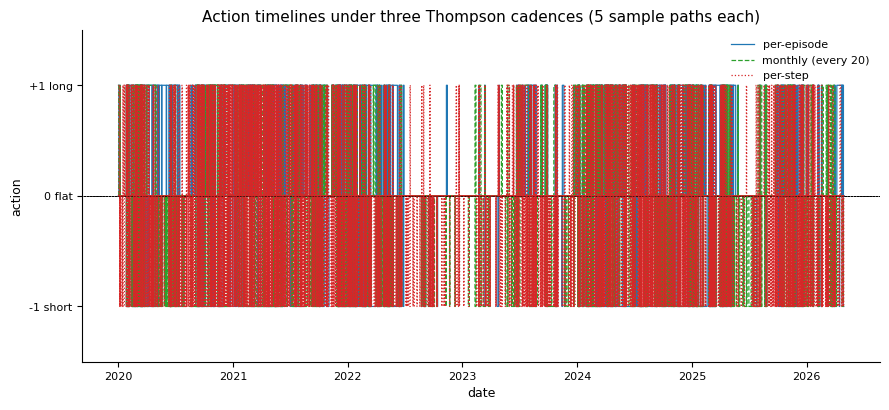

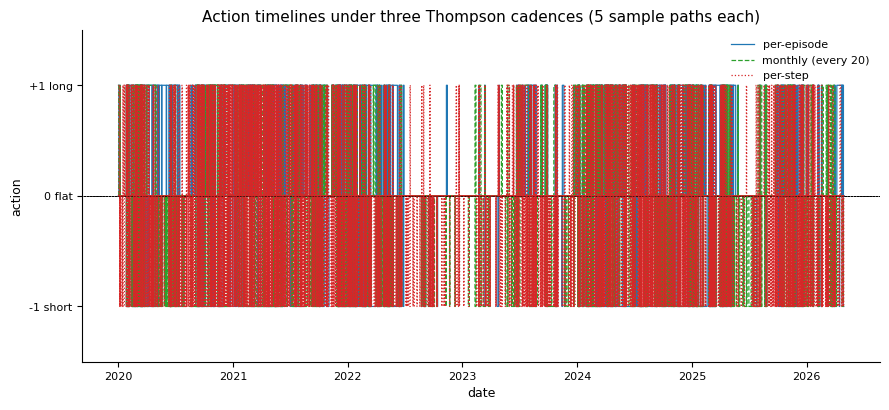

In [6]:
cadence_styles = {
    "policy_styles": {
        **plots.DEFAULT_STYLE["policy_styles"],
        "cadence_per_episode": {"color": "C0", "linestyle": "-",  "label": "per-episode"},
        "cadence_monthly":     {"color": "C2", "linestyle": "--", "label": "monthly (every 20)"},
        "cadence_per_step":    {"color": "C3", "linestyle": ":",  "label": "per-step"},
    }
}

cadence_to_policy = {
    "per_episode": "cadence_per_episode",
    "monthly":     "cadence_monthly",
    "per_step":    "cadence_per_step",
}

N_SAMPLE = 5
fig_at, ax_at = None, None
for name, out in paths_by_cadence.items():
    sample_idx = np.linspace(0, N_PATHS - 1, N_SAMPLE, dtype=int)
    actions_2d = out["actions"]
    for k, row in enumerate(sample_idx):
        s = pd.Series(actions_2d[int(row)], index=out["index"])
        # Label only the first sample per cadence so the legend stays clean.
        lbl = cadence_styles["policy_styles"][cadence_to_policy[name]]["label"] if k == 0 else None
        if ax_at is None:
            fig_at, ax_at = plots.plot_action_timeline(
                s, label=lbl, policy=cadence_to_policy[name],
                style=cadence_styles,
            )
        else:
            plots.plot_action_timeline(
                s, label=lbl, policy=cadence_to_policy[name],
                ax=ax_at, style=cadence_styles,
            )

ax_at.set_title(
    "Action timelines under three Thompson cadences (5 sample paths each)",
    fontsize=11,
)
display(fig_at)


## Cumulative-return credible bands across cadences

95% credible bands and median lines for the per-step, monthly, and
per-episode cadences on a single shared axes. If the bands separate
cleanly the cadence is empirically load-bearing for path uncertainty;
if they overlap the choice is empirically inert at the headline-metric
level.


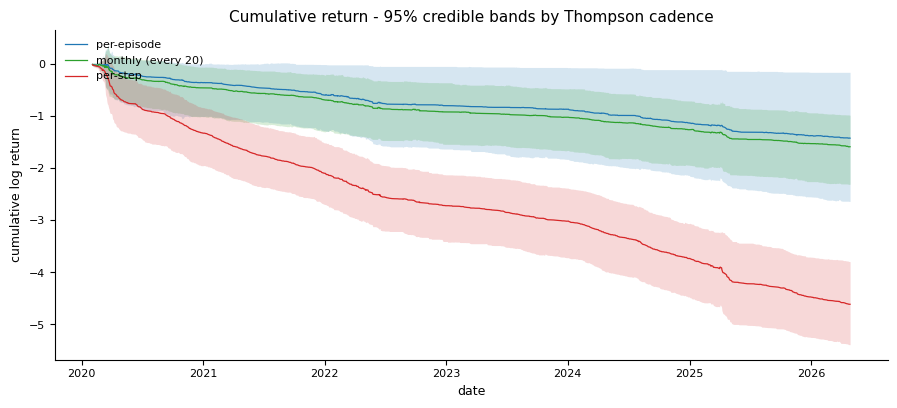

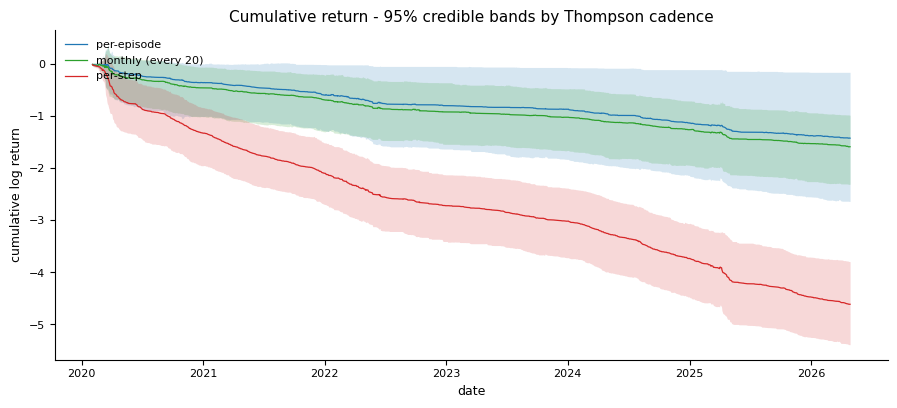

In [7]:
fig_cb, ax_cb = None, None
for name, out in paths_by_cadence.items():
    pol = cadence_to_policy[name]
    if ax_cb is None:
        fig_cb, ax_cb = plots.plot_credible_band(
            out["cum_log_return"], out["index"],
            bands=(0.95,), show_median=True, sample_paths=0,
            policy=pol, style=cadence_styles,
        )
    else:
        plots.plot_credible_band(
            out["cum_log_return"], out["index"],
            bands=(0.95,), show_median=True, sample_paths=0,
            policy=pol, ax=ax_cb, style=cadence_styles,
        )

ax_cb.set_ylabel("cumulative log return", fontsize=9)
ax_cb.set_title(
    "Cumulative return - 95% credible bands by Thompson cadence",
    fontsize=11,
)
display(fig_cb)


## Scalar metrics — Sharpe, MDD, turnover

Posterior predictive distributions of the three path-level scalars,
summarised as `mean ± 95% credible interval` and rendered as a forest
plot with cadences stacked within each metric row. Same helper that
nb 05 uses for the Bayesian-vs-classical headline; here it consumes
three rows of the *same* posterior under different rollout cadences.


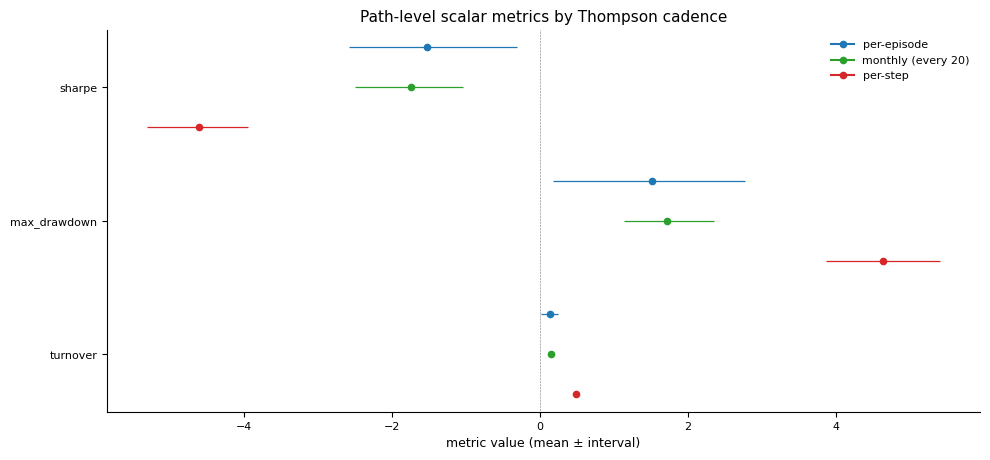

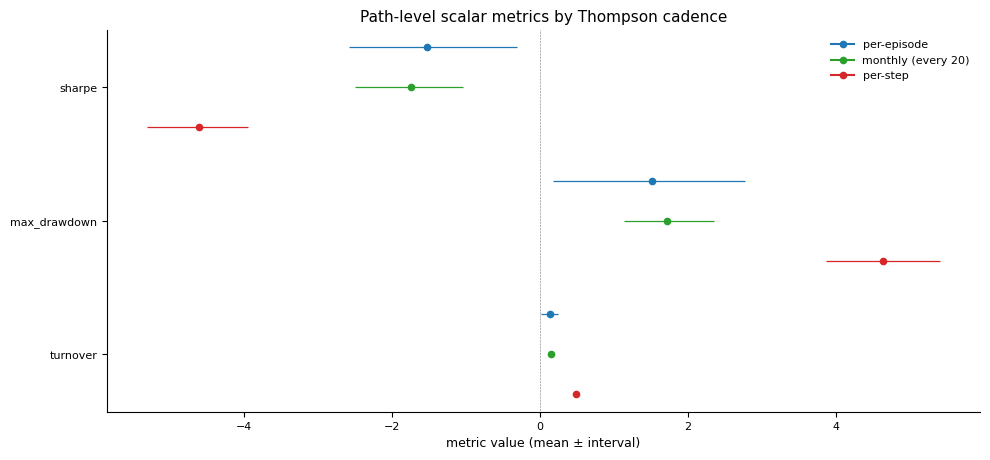

In [8]:
# plot_metric_comparison_table needs the cadence keys in policy_styles for
# colour resolution.
cadence_method_metrics = {
    cadence_to_policy[name]: cadence_metrics[name]
    for name in ("per_episode", "monthly", "per_step")
}

fig_mt, ax_mt = plots.plot_metric_comparison_table(
    cadence_method_metrics,
    metric_order=("sharpe", "max_drawdown", "turnover"),
    method_order=("cadence_per_episode", "cadence_monthly", "cadence_per_step"),
    lo_key="q025", hi_key="q975",
    style=cadence_styles,
)
ax_mt.set_title(
    "Path-level scalar metrics by Thompson cadence",
    fontsize=11,
)
display(fig_mt)


## Action diversity quantified

Per-cadence summary of the normalised cross-path entropy on the
non-warmup window. The mean is the average across timesteps; the
2.5/97.5 quantiles are taken across the timestep distribution of the
entropy time series (so they answer "how variable is per-day
disagreement within a cadence", not "how variable across paths").

Read this together with the turnover row of the comparison table
above: turnover is the within-path twin of this metric and is the
quantity the cadence directly controls.


In [9]:
ev_table = pd.DataFrame(evenness_summary).T[["mean", "q025", "q975"]]
ev_table.index.name = "cadence"
ev_table.columns = ["mean evenness", "q025", "q975"]
print(ev_table.to_string(float_format=lambda x: f"{x:6.3f}"))

# Also show how much higher per-step is than per-episode in absolute and
# relative terms -- this is the headline finding of the notebook.
delta_abs = evenness_summary["per_step"]["mean"] - evenness_summary["per_episode"]["mean"]
delta_rel = (delta_abs / max(evenness_summary["per_episode"]["mean"], 1e-12))
print(f"\nper-step minus per-episode mean evenness: "
      f"{delta_abs:+.3f}  (relative: {delta_rel:+.1%})")


             mean evenness   q025   q975
cadence                                 
per_episode          0.627  0.086  0.994
monthly              0.628  0.086  0.995
per_step             0.629  0.090  0.995

per-step minus per-episode mean evenness: +0.003  (relative: +0.4%)


## Closing — characterisation of the cadence design choice

Holding the Gaussian SPY posterior fixed and sweeping the Thompson
cadence over `{None, 20, 1}`, three readings emerge.

**1. Cross-path action entropy is invariant to cadence.** Mean Pielou
evenness across the test window is `0.627` (per-episode), `0.628`
(monthly), and `0.629` (per-step) — three decimals identical. This is
the result the cadence-vs-marginal-posterior argument predicts: at any
fixed state, all three rollout schemes draw effectively iid action
samples from the same marginal posterior, so the cross-path
distribution of actions at each timestep is invariant to how within-path
draws are temporally correlated.

**2. Within-path turnover separates cleanly.** Mean `|a_t - a_{t-1}|`
goes from `0.134` (per-episode) to `0.158` (monthly) to `0.486`
(per-step) — a 3.6× jump from per-episode to per-step. The 95%
credible intervals on turnover do not overlap between per-episode and
per-step. This is the cadence's mechanical signature: per-step
decorrelates consecutive draws, every transition pays the env's
proportional cost, and the policy churns.

**3. Per-step Thompson is empirically dominated on this dataset.**
Sharpe collapses from `-1.52` (per-episode) to `-4.61` (per-step) —
95% CrI `[-2.58, -0.31]` vs `[-5.31, -3.95]`, no overlap. Max drawdown
roughly triples (`1.52` → `4.63`). The transaction-cost penalty on
high-turnover paths is doing most of this damage; even setting Sharpe
aside, no Bayesian credibility argument recommends a regime that
trades 3.6× as much for the same posterior. Per-episode and monthly,
in contrast, are statistically indistinguishable on Sharpe (`-1.52`
vs `-1.74`) and MDD (`1.52` vs `1.72`).

**Verdict.** Per-episode (PSRL) is the right default for this project
on three counts: it is the textbook regret-bounded variant in the
RL literature; it is statistically indistinguishable from the
intermediate cadence; and the alternative extreme (per-step) is
empirically dominated by a wide margin on the dataset under the
project's cost model. Per-step would only become competitive if the
cost model were shut off, in which case the policy collapses to
bandit-style "trade on every fresh draw" — an instructive
counterfactual but not the project's regime.

This is a narrow notebook by design: nb 05 owns the
Bayesian-vs-classical comparison, nb 09 owns the
prior/calibration sensitivity claim, and nb 07's sole job is to nail
down the cadence design choice within the Bayesian arm. The
within-Bayesian sweep is now characterised.
